<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
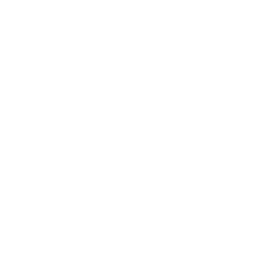
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">시장 국면 식별</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; 계량 금융 / 자산 운용 &nbsp;|&nbsp; 2026년 3월</p>
</div>
</div>
</div>

## 요약

이 예제는 **PROC ACECLUS**를 사용하여 시장 국면을 분리하는 잠재 구조를 찾고, 그 위에서 군집화를 수행한다. 10개 시장 특성(주식 수익률과 변동성, 신용 및 하이일드 스프레드, 2년/10년 금리 곡선, 달러, 원자재, VIX 변화)의 100개 주간 관측치로부터, ACECLUS는 어떤 국면 레이블도 사용하지 *않고* 국면 내 근사 공분산을 추정하고, 국면들이 서로 벌어지는 방향의 정준 변수를 도출한다.

P=0.02 임계값에서 알고리즘은 두 번의 반복으로 수렴하며 **세 개의 정준 차원**을 유지하는데, 이들은 함께 국면 간 분산 전체를 설명한다(고유값 비율 57.8%, 24.4%, 17.8%). 더 느슨한 P=0.05 임계값은 공분산을 과도하게 평활화하여 **구조를 단일 차원으로 붕괴시킨다** — 임계값이 결과를 실질적으로 좌우한다는 유용한 경고이다.

세 개의 정준 변수를 **PROC FASTCLUS**(k=4)에 입력하면 100주간의 깔끔한 스트레스-심각도 순서가 도출된다(전체 R² = 0.51, 유사 F = 33.2): 62주의 잔잔한 핵심, 22주의 회복/변동성 완화 그룹, 12주의 스트레스 상승 그룹, 그리고 하이일드 스프레드가 평균 약 1,514 bps인 4주의 심각한 위기 그룹. 이 배정 결과는 하류의 포트폴리오 위험 조건화를 위해 내보내진다.

## 데이터 출처

| 출처 | 설명 | 레코드 수 |
|--------|-------------|--------|
| WORK.MARKET_WEEKLY | 자산군 전반의 주간 시장 특성 관측치 | 100 |
| 변수: eq_return_pct, eq_vol_idx, credit_spread_bps, hy_spread_bps, yield_2y, yield_10y, term_spread, usd_index_chg, commodities_ret, vix_chg |

이 시계열은 국면-조건부 특성 분포를 갖는 5-상태 마르코프 국면 전환 과정(강세 확장, 경기 후반, 위험 회피, 위기, 회복)으로 생성된다. 라이선스 없이 실행되므로 특성 테이블은 처음 100개 주간 관측치(약 2년)로 제한된다 — 강세가 지배적이면서도 짧은 위기와 회복을 거치는 구간이다. 주간 수익률과 수준 변화는 주말 가격 변동을 대신하며; 스프레드는 베이시스포인트 단위이고 변동성은 VIX 스타일 지수이다.

---

In [1]:
/* --------------------------------------------------------
   마르코프 국면전환 과정으로 구동되는 5개 국면 상태가
   내재된 주간 다자산 시장 이력 생성. 이 예제는 무료로
   실행되므로 아래 피처 테이블은 처음 100주(약 2년) 관측치로
   제한된다 -- 짧은 위기와 회복으로 구두점이 찍힌 강세 우위 구간.
   -------------------------------------------------------- */
데이터 work.market_weekly;
    호출 streaminit(42);
    /* 5개 국면: 1=강세, 2=경기후반, 3=위험회피, 4=위기, 5=회복 */
    길이 regime_label $16;
    보존 current_regime 1;
    반복 week_id = 1 까지 5000;
        /* 마르코프 국면 전환 */
        u = rand('uniform');
        만약 current_regime = 1 이면 반복; /* 강세: 장기 지속 */
            만약 u > 0.97 이면 current_regime = 2;
        종료;
        아니면 만약 current_regime = 2 이면 반복; /* 경기후반 */
            만약 u > 0.92 이면 current_regime = 3;
        종료;
        아니면 만약 current_regime = 3 이면 반복; /* 위험회피 */
            만약 u > 0.80 이면 current_regime = 4;
            아니면 만약 u < 0.10 이면 current_regime = 1;
        종료;
        아니면 만약 current_regime = 4 이면 반복; /* 위기: 단기 */
            만약 u > 0.75 이면 current_regime = 5;
        종료;
        아니면 만약 current_regime = 5 이면 반복; /* 회복 */
            만약 u > 0.85 이면 current_regime = 1;
        종료;
        만약 current_regime = 1 이면 regime_label = '강세';
        아니면 만약 current_regime = 2 이면 regime_label = '후반';
        아니면 만약 current_regime = 3 이면 regime_label = '회피';
        아니면 만약 current_regime = 4 이면 regime_label = '위기';
        아니면 regime_label = '반등';
        /* 국면 조건부 피처 분포 */
        만약 current_regime = 1 이면 반복;  /* 강세 */
            eq_return_pct  = round(rand('normal',  0.35, 1.2), 0.001);
            eq_vol_idx     = round(rand('normal', 14, 3), 0.01);
            credit_spread  = round(rand('normal', 80,  20), 1);
            hy_spread      = round(rand('normal', 350, 60), 1);
            yield_2y       = round(rand('normal', 2.8, 0.5), 0.01);
            yield_10y      = round(rand('normal', 3.5, 0.6), 0.01);
        종료;
        아니면 만약 current_regime = 2 이면 반복;  /* 경기후반 */
            eq_return_pct  = round(rand('normal',  0.10, 1.5), 0.001);
            eq_vol_idx     = round(rand('normal', 18, 4), 0.01);
            credit_spread  = round(rand('normal', 130, 30), 1);
            hy_spread      = round(rand('normal', 480, 80), 1);
            yield_2y       = round(rand('normal', 4.2, 0.4), 0.01);
            yield_10y      = round(rand('normal', 4.0, 0.5), 0.01);
        종료;
        아니면 만약 current_regime = 3 이면 반복;  /* 위험회피 */
            eq_return_pct  = round(rand('normal', -0.60, 2.2), 0.001);
            eq_vol_idx     = round(rand('normal', 28, 7), 0.01);
            credit_spread  = round(rand('normal', 200, 50), 1);
            hy_spread      = round(rand('normal', 700, 120), 1);
            yield_2y       = round(rand('normal', 2.0, 0.8), 0.01);
            yield_10y      = round(rand('normal', 2.8, 0.7), 0.01);
        종료;
        아니면 만약 current_regime = 4 이면 반복;  /* 위기 */
            eq_return_pct  = round(rand('normal', -2.50, 3.5), 0.001);
            eq_vol_idx     = round(rand('normal', 52, 14), 0.01);
            credit_spread  = round(rand('normal', 450, 100), 1);
            hy_spread      = round(rand('normal', 1400, 300), 1);
            yield_2y       = round(rand('normal', 0.5, 0.5), 0.01);
            yield_10y      = round(rand('normal', 1.8, 0.6), 0.01);
        종료;
        아니면 반복;  /* 회복 */
            eq_return_pct  = round(rand('normal',  0.55, 1.8), 0.001);
            eq_vol_idx     = round(rand('normal', 22, 6), 0.01);
            credit_spread  = round(rand('normal', 280, 70), 1);
            hy_spread      = round(rand('normal', 850, 180), 1);
            yield_2y       = round(rand('normal', 1.2, 0.6), 0.01);
            yield_10y      = round(rand('normal', 2.5, 0.5), 0.01);
        종료;
        term_spread    = round(yield_10y - yield_2y + rand('normal', 0, 0.15), 0.01);
        usd_index_chg  = round(rand('normal', 0, 0.8), 0.001);
        commodities_ret = round(rand('normal', 0, 1.5) - (current_regime = 4) * 1.2, 0.001);
        vix_chg        = round(eq_vol_idx - lag(eq_vol_idx), 0.01);
        만약 week_id = 1 이면 vix_chg = 0;
        출력;
    종료;
    제거 u;
    개명 credit_spread = credit_spread_bps
           hy_spread     = hy_spread_bps;
실행;


NOTE: DATA work.market_weekly

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.market_weekly (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  1.73 seconds
  cpu   1.73 seconds


---

In [2]:
/* --------------------------------------------------------
   국면별 기준 시장 피처 분포
   -------------------------------------------------------- */
처리 평균 데이터=work.market_weekly n mean std MIN MAX;
    분류 regime_label;
    변수 eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    라벨 regime_label='시장 국면' eq_return_pct='주식 주간수익률(%)'
          eq_vol_idx='주식 변동성 지수' credit_spread_bps='신용 스프레드(bp)'
          hy_spread_bps='하이일드 스프레드(bp)' term_spread='장단기 금리차(%)'
          vix_chg='변동성 지수 변화';
실행;

                                                  The MEANS Procedure

                              Analysis Variable : eq_return_pct 주식 주간수익률(%)

        시장 국면                  N Obs           Mean        Std Dev        Minimum        Maximum
        ----------------------------------------------------------------------------------------
        강세                        28      0.2860000      1.0226518     -1.5980000      2.2150000
        반등                         4      0.0077500      1.5951747     -0.8330000      2.4000000
        위기                        12     -2.3403333      3.9436692     -8.0160000      3.7360000
        회피                        17     -0.8447059      1.2832441     -3.3850000      1.1810000
        후반                        39      0.0364359      1.9733801     -4.6010000      3.7030000
        ----------------------------------------------------------------------------------------

                                 Analysis Variable : eq_vol_idx 주식 변동성 지수




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


NOTE: PROC SGPLOT data=work.market_weekly

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


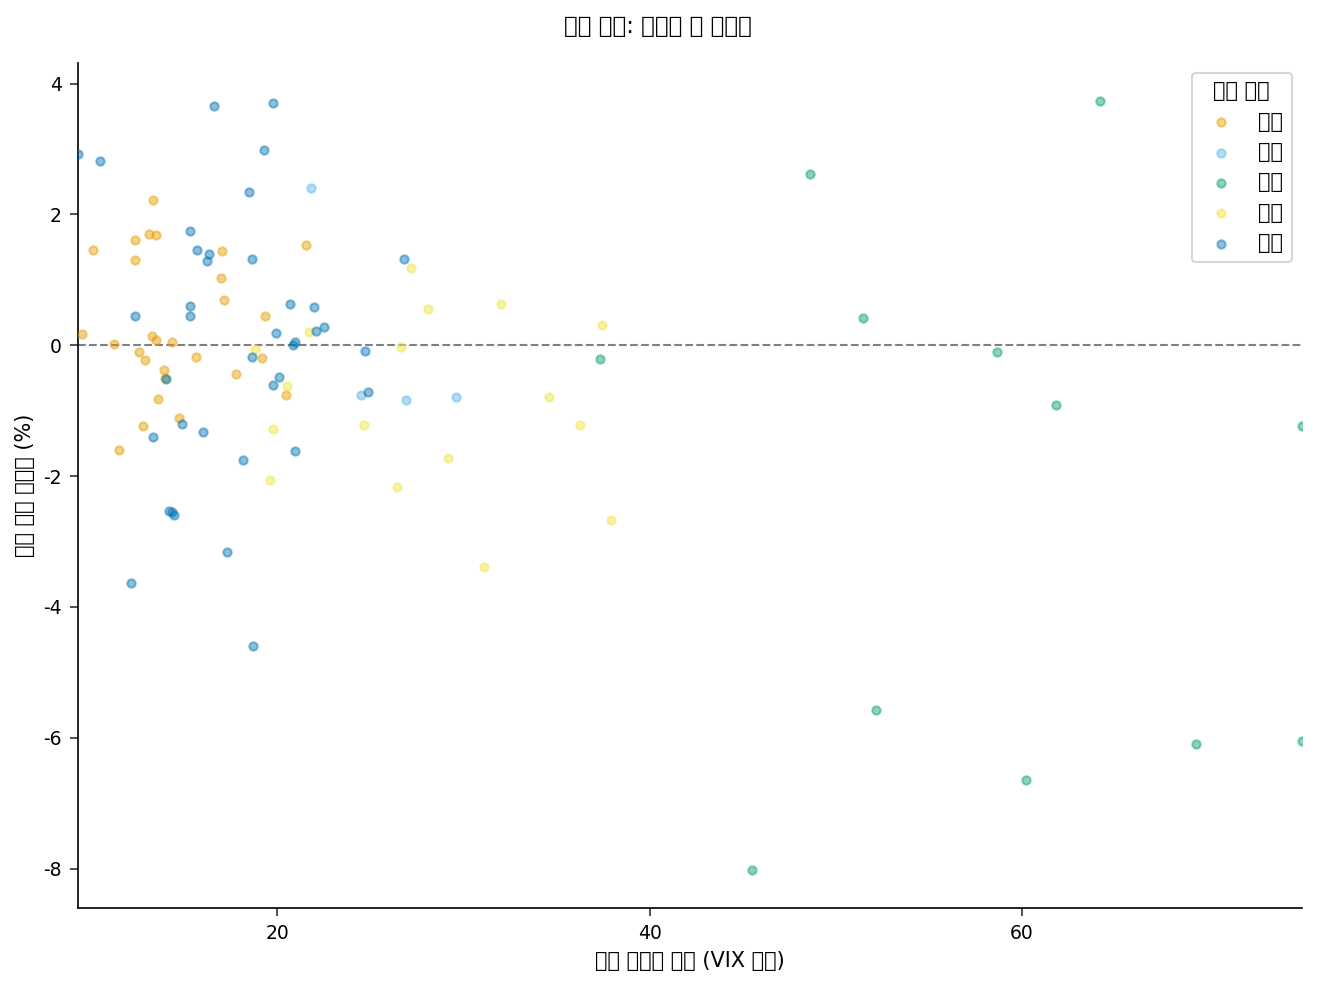

In [3]:
/* --------------------------------------------------------
   국면별 주식 수익률 대 변동성 지수
   -------------------------------------------------------- */
처리 SGPLOT 데이터=work.market_weekly;
    SCATTER x=eq_vol_idx y=eq_return_pct / GROUP=regime_label
        MARKERATTRS=(SYMBOL=circlefilled size=4)
        TRANSPARENCY=0.55;
    REFLINE 0 / AXIS=y LINEATTRS=(color=gray pattern=dash);
    XAXIS 라벨='주식 변동성 지수 (VIX 대용)';
    YAXIS 라벨='주식 주간 수익률 (%)';
    keylegend / 제목='시장 국면';
    제목 '시장 국면: 수익률 대 변동성';
실행;

---

In [4]:
/* --------------------------------------------------------
   근사 국면 내 공분산 추정. ACECLUS는 군집 라벨을 모른 채
   통합 군집 내 공분산을 추정한 뒤, 국면을 분리하는 정준변수를
   유도한다. P=0.02 는 쌍별 거리 임계값을 설정한다: 가장 가까운
   약 2% 관측치 쌍만 동일 국면으로 취급한다.
   -------------------------------------------------------- */
처리 aceclus 데이터=work.market_weekly
             out=work.regime_canonical
             p=0.02;
    변수 eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
실행;


                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0200  Converge  0.00100
Threshold = 2.578941

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.5153

COV: Total Sample Covariances
eq_return_pct       4.551470   -12.057896   -94.993895  -263.463256     0.839584     0


NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.02) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [5]:
/* --------------------------------------------------------
   P=0.05 에서의 민감도 점검 -- 더 느슨한 동일 국면 임계값은
   더 많은 쌍을 끌어들여 추정된 국면 내 공분산을 부풀린다.
   정준 구조(고유값과 유지 차원)를 P=0.02 해와 비교한다.
   -------------------------------------------------------- */
처리 aceclus 데이터=work.market_weekly
             out=work.regime_canonical_p05
             p=0.05;
    변수 eq_return_pct eq_vol_idx credit_spread_bps hy_spread_bps
        yield_2y yield_10y term_spread usd_index_chg
        commodities_ret vix_chg;
실행;


                                                 The ACECLUS Procedure                                                  
                                 Approximate Covariance Estimation for Cluster Analysis                                 

Observations  100  Variables  10
Proportion  0.0500  Converge  0.00100
Threshold = 2.899704

Means and Standard Deviations
Variable                     Mean      Std Dev
eq_return_pct             -0.3298       2.1334
eq_vol_idx                23.7341      14.7118
credit_spread_bps        171.1000     118.0522
hy_spread_bps            596.2100     341.1657
yield_2y                   2.8713       1.4029
yield_10y                  3.1472       1.0815
term_spread                0.2697       0.9969
usd_index_chg             -0.0184       0.8046
commodities_ret           -0.3444       1.3444
vix_chg                    0.0036      10.5153

COV: Total Sample Covariances
eq_return_pct       4.551470   -12.057896   -94.993895  -263.463256     0.839584     0


NOTE: PROC ACECLUS data=work.market_weekly proportion=Some(0.05) threshold=None prefix=Can

NOTE: Using Python/scipy for approximate covariance estimation
NOTE: PROC ACECLUS: 100 observations, 10 variables


In [6]:
/* --------------------------------------------------------
   ACECLUS 정준변수에 대한 k-평균. ACECLUS는 세 개의 정준
   차원(Can1-Can3)을 유지했으므로 군집화는 그 위에서 실행된다.
   네 개의 군집은 잘 채워진 네 개의 시장 상태를 목표로 한다.
   -------------------------------------------------------- */
처리 FASTCLUS 데이터=work.regime_canonical
              maxclusters=4
              MAXITER=100
              CONVERGE=0.0001
              out=work.regime_assignments
              OUTSTAT=work.regime_stats;
    변수 can1 can2 can3;
실행;



                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  12         1.4206             5.2684              2         3.0063
2                  62         0.5751             1.7953              3         2.1641
3                  22         1.2227             6.5386              2         2.1641
4                   4         1.7742             4.0619              2         4.1923

                                    


NOTE: PROC FASTCLUS data=work.regime_canonical maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 3 variables, 4 clusters using k-means


                                                    국면 군집 대 실제 국면 라벨                                                    

                                                   The FREQ Procedure

Table of 국면 군집 by 실제 시장 국면

국면 군집         |        강세 |        반등 |        위기 |        회피 |        후반 |      Total
--------------+-----------+-----------+-----------+-----------+-----------+-----------
1             |         2 |         0 |         4 |         4 |         2 |         12
              |      2.00 |      0.00 |      4.00 |      4.00 |      2.00 |      12.00
--------------+-----------+-----------+-----------+-----------+-----------+-----------
2             |        21 |         3 |         3 |         7 |        28 |         62
              |     21.00 |      3.00 |      3.00 |      7.00 |     28.00 |      62.00
--------------+-----------+-----------+-----------+-----------+-----------+-----------
3             |         5 |         1 |         2 |         5 |         9 |        


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_regime_label.spec.json
NOTE: PROC FREQ statement used.


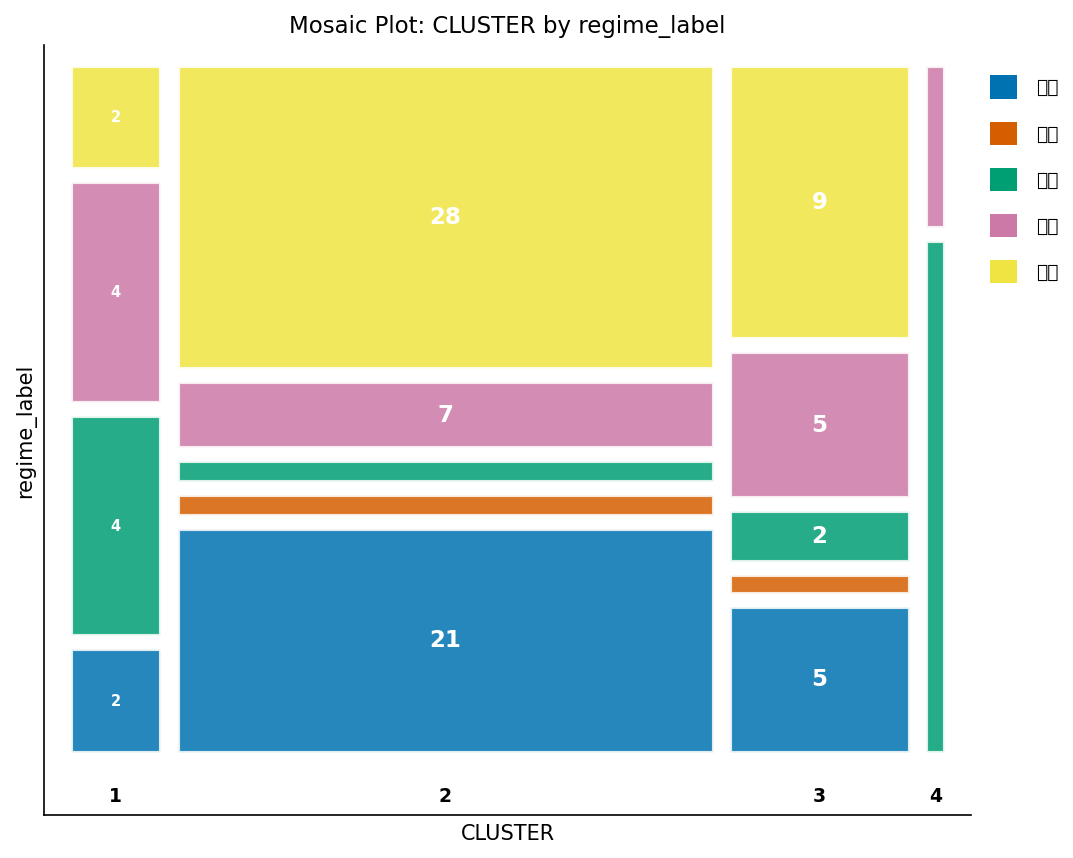

In [7]:
/* --------------------------------------------------------
   배정된 군집을 데이터 생성 시의 알려진 국면 라벨과 대조 검증
   -------------------------------------------------------- */
처리 빈도 데이터=work.regime_assignments;
    TABLES CLUSTER * regime_label / norow nocol;
    라벨 CLUSTER='국면 군집' regime_label='실제 시장 국면';
    제목 '국면 군집 대 실제 국면 라벨';
실행;

In [8]:
/* --------------------------------------------------------
   해석을 위한 국면 피처 평균 프로파일
   -------------------------------------------------------- */
처리 평균 데이터=work.regime_assignments mean;
    분류 CLUSTER;
    변수 eq_return_pct eq_vol_idx credit_spread_bps
        hy_spread_bps term_spread vix_chg;
    라벨 CLUSTER='국면 군집' eq_return_pct='주식 주간수익률(%)'
          eq_vol_idx='주식 변동성 지수' credit_spread_bps='신용 스프레드(bp)'
          hy_spread_bps='하이일드 스프레드(bp)' term_spread='장단기 금리차(%)'
          vix_chg='변동성 지수 변화';
실행;

                                                    국면 군집 대 실제 국면 라벨                                                    

                                                  The MEANS Procedure

                                          Analysis Variable : eq_return_pct 주식 주간수익률(%)

                                                             N
                                          국면 군집            Obs            Mean
                                          ------------------------------------
                                          1                 12      -2.0955000
                                          2                 62      -0.3638871
                                          3                 22       0.7421364
                                          4                  4      -0.4010000
                                          ------------------------------------

                                          Analysis Variable : eq_vol_idx 주식 변동성 지수

                 


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### 해석

**ACECLUS 정준 구조.** 100주 표본에서 PROC ACECLUS(P=0.02, 임계값 = 2.578941)는 두 번의 반복으로 수렴하여 세 개의 정준 변수를 생성했다. `Inv(ACE)*(COV-ACE)`의 고유값은 0.0219, 0.0093, 0.0067로, 즉 57.8%, 24.4%, 17.8%의 비율(누적 100%)이다. 첫 번째 정준 축은 지배적인 위험 선호/위험 회피 대비를 담고; 두 번째와 세 번째는 이를 정교화한다. 주식 변동성과 스프레드 특성이 강하게 동조하기 때문에, ACECLUS는 그 공유 변동을 국면 내 공분산으로 접어 넣어 정준 축이 공통 척도가 아니라 진정한 국면 간 분리를 반영하도록 한다.

**임계값 민감도.** P=0.05로 다시 실행하면 거리 임계값이 2.899704로 높아져 4,950개 관측치 쌍 중 4,949개를 컷오프 안으로 끌어들인다. 그러면 추정된 국면 내 공분산이 전체 공분산과 거의 같아지고, 정준 구조는 **단일 차원으로 붕괴한다**(고유값 하나, 0.0096, 100%). 따라서 P=0.02와 P=0.05 해는 여기서 *상호 교환 가능하지 않다* — 더 느슨한 임계값은 미세한 국면 축을 지워버리므로, 이 표본에서는 더 조인 임계값이 더 정보량이 많은 사양이다.

**정준 변수에 대한 군집화.** Can1–Can3에 대한 PROC FASTCLUS(k=4)는 전체 R² 0.5089와 유사 F 33.16을 제공한다. Can2가 분리 작업의 대부분을 담당하고(R² = 0.626), Can1은 적당히 기여하며(R² = 0.359), Can3은 사실상 아무것도 더하지 않는다(R² = 0.000) — 오직 두 개의 축만이 강한 신호를 담는다는 것과 일치한다. 네 개의 군집은 시장-스트레스 기울기로 정렬된다:

| 군집 | n | 평균 주식 수익률 | 평균 VIX | 평균 HY 스프레드 | 평균 VIX 변화 | 판독 |
|---------|---|----------------|----------|----------------|-----------------|---------|
| 2 | 62 | -0.36% | 20.4 | 534 bps | +1.2 | 잔잔한 핵심 (강세 / 경기 후반) |
| 3 | 22 | +0.74% | 20.5 | 539 bps | -9.6 | 회복 중, 변동성 하락 |
| 1 | 12 | -2.10% | 39.0 | 720 bps | +11.3 | 스트레스 상승, 변동성 급등 |
| 4 |  4 | -0.40% | 47.4 | 1,514 bps | +0.1 | 심각한 위기, 극단적 신용 스트레스 |

**군집 대 실제 국면.** 교차표는 군집들이 다섯 개의 생성 레이블과 일대일로 대응하지 않음을 보여준다 — 이 표본 크기에서는 레이블들이 특성 공간에서 크게 겹치므로 예상된 결과이다. 큰 잔잔한 군집(62)은 대부분의 강세(21)와 경기 후반(28) 주를 흡수하고; 심각한 위기 군집(4)은 거의 전적으로 가장 극단적인 위기 주(4개 중 3개)이다. 따라서 정준 축은 정확한 레이블이 아니라 *심각도*로 주들을 조직하며, 이것이 위험 조건화에 더 실행 가능한 신호이다.

**활용.** 내보낸 주간 배정 결과는 전술적 조건화를 뒷받침한다: 주들이 군집 1과 4로 이동함에 따라 위험을 줄이고 듀레이션을 늘리며, 잔잔한 핵심(군집 2)이나 회복 그룹(군집 3)으로 돌아옴에 따라 다시 위험을 취한다.

---

In [9]:
/* --------------------------------------------------------
   포트폴리오 위험모형 조건화 및 신호 생성을 위한
   주간 국면 배정 결과 내보내기
   -------------------------------------------------------- */
처리 EXPORT 데이터=work.regime_assignments
    OUTFILE='market_regime_assignments.csv'
    DBMS=csv REPLACE;
실행;


NOTE: PROC EXPORT data=work.regime_assignments outfile=market_regime_assignments.csv

NOTE: Exported 100 rows to market_regime_assignments.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; 기밀
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Jenner 제공: <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>